In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
# Read calibration data into pd DataFrame
df = pd.DataFrame()
for chunk in pd.read_csv('C:/Users/burri/Documents/PET/TimeCalibration/TimeCalibrationMiniPET/VerticalMotion_HighIntSource_800sec_coinc.dat', usecols=[2, 3, 4, 7, 8, 9], delimiter="\t", header=None, chunksize=1000000):
    # Name columns
    chunk.columns = ['TimeL', 'EnergyL', 'IDL', 'TimeR', 'EnergyR', 'IDR']
    # Convert Left channel to mod 128
    chunk['IDL'] = chunk['IDL'] % 128
    # Time difference column
    chunk['TimeDiff'] = chunk['TimeL'] - chunk['TimeR']
    
    df = pd.concat([df, chunk], ignore_index=True)

# Convert to numpy array, faster
arr = df.to_numpy()


In [ ]:
temp = []
for row in arr:
    if row[2] == 3 and row[5] == 10:
        temp.append(row)
np.savetxt(temp, )

TypeError: savetxt() missing 1 required positional argument: 'X'

In [8]:
coincidences_matrix = [[[] for i in range(128)] for j in range(128)]

# Creates coincidence matrix containing TimeDiffs (relative to x=0) for every LOR 
for row in arr:
    coincidences_matrix[int(row[2])][int(row[5])].append(row[6])

# Array for storing left and right module channel time offsets, these will be used to calculate per channel offset values
coincidences_arr_l = [[] for i in range(128)]
coincidences_arr_r = [[] for i in range(128)]

# Fill arrays
for l in range(128):
    for r in range(128):
        coincidences_arr_l[l].extend(coincidences_matrix[l][r])
        coincidences_arr_r[r].extend(coincidences_matrix[l][r])

print(sorted([len(l) for l in coincidences_arr_l]))
print(sorted([len(r) for r in coincidences_arr_r]))

[75, 100, 136, 143, 201, 213, 239, 246, 264, 278, 291, 291, 375, 413, 423, 443, 519, 532, 535, 547, 587, 616, 762, 1069, 1465, 1622, 1709, 1915, 2691, 2702, 3276, 3525, 4652, 5225, 5437, 11108, 12097, 13093, 13749, 13983, 14017, 14750, 15454, 16116, 16339, 16557, 16669, 16847, 17113, 17538, 17693, 18468, 18468, 18590, 18599, 18910, 19519, 19743, 20769, 20895, 21607, 22605, 24229, 24348, 24363, 25318, 25661, 25746, 26300, 26320, 26331, 26429, 26485, 26502, 26561, 26823, 27390, 27551, 27691, 27757, 27771, 28096, 28904, 28995, 29099, 29872, 30192, 30301, 30313, 30373, 30830, 31729, 32398, 32509, 32822, 33237, 34524, 35968, 36551, 36744, 37203, 38321, 40528, 41097, 42749, 44340, 44527, 44913, 49921, 54107, 54556, 56720, 58079, 59466, 61065, 62916, 64800, 64917, 66051, 66694, 67154, 68307, 85463, 86315, 100792, 128550, 140272, 179746]
[177, 210, 220, 245, 307, 309, 316, 327, 331, 340, 363, 574, 779, 791, 839, 860, 993, 1160, 1268, 1307, 1395, 1667, 1715, 1869, 2063, 2218, 2340, 2481, 2536, 

1170


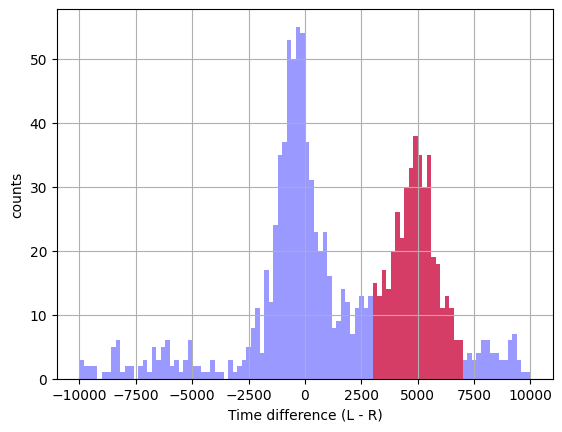

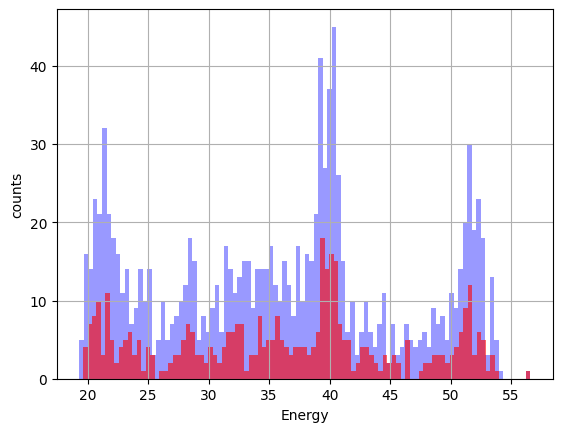

In [10]:
# Looking at left channels

lookatrange = (3000, 7000)

#
temp = []

for coinc in arr:
    if coinc[2] == 3 and coinc[5] == 10:
        temp.append(coinc)

print(len(temp))

temptimediffs = []
tempenergies = []
for x in temp:
    temptimediffs.append(x[6])
    tempenergies.append(x[1])

plt.hist(temptimediffs, bins = range(-10000, 10001, 200), color = 'blue', alpha = 0.4)


bigtimediffs = []
bigenergies = []
for x in temp:
    if x[6] > lookatrange[0] and x[6] < lookatrange[1]:
        bigtimediffs.append(x[6])
        bigenergies.append(x[1])

plt.hist(bigtimediffs, bins = range(-10000, 10001, 200), color = 'red', alpha = 0.6)

plt.xlabel('Time difference (L - R)')
plt.ylabel('counts')
plt.grid()
plt.show()


plt.hist(tempenergies, bins = 100, color = 'blue', alpha = 0.4)
plt.hist(bigenergies, bins = 100, color = 'red', alpha = 0.6)

plt.xlabel('Energy')
plt.ylabel('counts')
plt.grid()
plt.show()

In [9]:
for idl in coincidences_arr_l:
    print(len(idl))

3525
19519
25318
66051
246
64800
264
58079
291
85463
201
18468
54556
17113
61065
239
762
29872
26331
16116
18590
40528
27771
75
86315
27390
56720
68307
5437
213
11108
136
15454
27551
30313
1709
179746
30301
16557
291
100
28096
2702
54107
375
26502
14017
34524
24229
24348
59466
1915
37203
22605
26485
26429
21607
13749
616
443
44913
30192
13983
17538
35968
26320
3276
26300
16339
1069
140272
32398
14750
44340
28904
38321
19743
18599
32822
519
42749
17693
18910
67154
547
26561
36744
532
33237
16669
20895
1622
32509
29099
1465
12097
62916
423
128550
26823
587
49921
41097
4652
28995
18468
27757
24363
27691
20769
25661
278
31729
66694
44527
100792
25746
64917
16847
30830
30373
36551
535
413
2691
143
5225
13093


18590


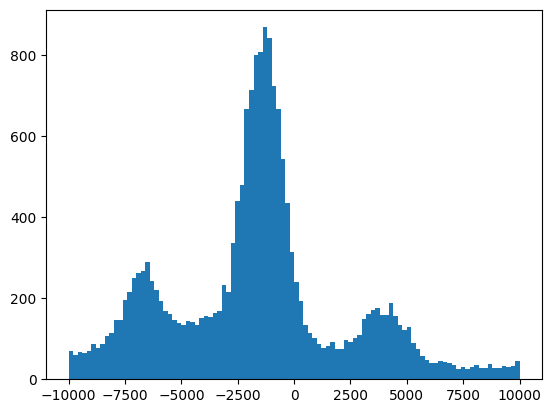

In [51]:
idl = 20
plt.hist(coincidences_arr_l[idl], bins = 100)
print(len(coincidences_arr_l[idl]))
plt.show()

60338


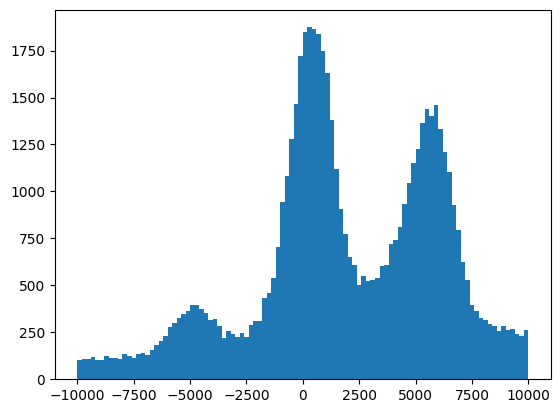

In [53]:
idr = 10
plt.hist(coincidences_arr_r[idr], bins = 100)
print(len(coincidences_arr_r[idr]))
plt.show()

In [66]:
# Define gaussian fit
def gaussian(x, a, mu, c):
    return a * np.exp(-(x - mu)**2 / (2 * c**2))

[  57.49410924 -270.88082316 1597.72261746]


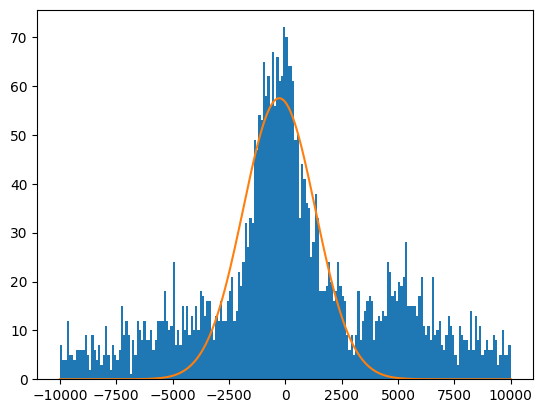

In [82]:
# With only gaussian

l = 0

# Create histogram
counts, bins = np.histogram(coincidences_arr_l[l], bins = 200)
# Initial guess for amplitude
inita = 0.8 * np.max(counts)
# Initial guess for mean
initmu = bins[:-1][np.where(counts == np.max(counts))[0][0]]
                    
try:
    # try fit, with bad stats the fit sometimes doesn't work
    popt = curve_fit(gaussian, bins[:-1], counts, p0 = [inita, initmu, 500])[0]
    # Check that mean is reasonable 
    if abs(popt[1]) < 10000: # 10000
        print(popt)
        plt.hist(coincidences_arr_l[l], bins = 200)
        plt.plot(np.linspace(-10000, 10000, 300), gaussian(np.linspace(-10000, 10000, 300), *popt))
except:
        pass
plt.show()

99
[  63.76943387 -283.84576056 1264.21894851]


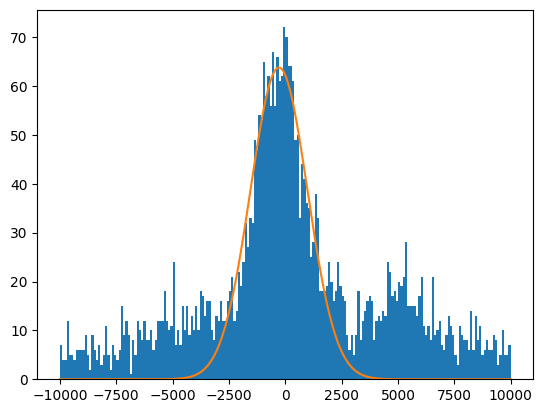

In [83]:
# With range cut

l = 0

# Create histogram
counts, bins = np.histogram(coincidences_arr_l[l], bins = 200)
# Initial guess for amplitude
inita = 0.8 * np.max(counts)
# Initial guess for mean
maxindex = np.where(counts == np.max(counts))[0][0]
print(maxindex)
initmu = bins[:-1][maxindex]
# Bins to fit over
binl, binr = maxindex - 25, maxindex + 25                    

# try fit, with bad stats the fit sometimes doesn't work
popt = curve_fit(gaussian, bins[:-1][binl:binr], counts[binl:binr], p0 = [inita, initmu, 500])[0]
# Check that mean is reasonable 
if abs(popt[1]) < 10000: # 10000
    print(popt)
    plt.hist(coincidences_arr_l[l], bins = 200)
    plt.plot(np.linspace(-10000, 10000, 300), gaussian(np.linspace(-10000, 10000, 300), *popt))

plt.show()